# One-at-a-time aberration hill climbing

This notebook optimizes a selected HAADF image metric by changing exactly one aberration at a time. All candidate metrics are displayed throughout the run. Run the setup cells once, then run only the aberration cell you want.

The correction calls are incremental: every unsuccessful trial is reversed before continuing. Start with conservative step sizes and keep the beam on a stable, feature-rich region.

In [1]:
%matplotlib widget

import json
import os

import matplotlib.pyplot as plt
import numpy as np
import tango
from IPython.display import clear_output, display
from tiled.client import from_uri

# The shared Tango database, microscope devices, and Tiled run here.
TANGO_DATABASE_HOST = "10.46.217.241"
TANGO_DATABASE_PORT = 9094
os.environ["TANGO_HOST"] = f"{TANGO_DATABASE_HOST}:{TANGO_DATABASE_PORT}"

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")
corrector = tango.DeviceProxy("asyncroscopy/corrector/default")

for proxy in (scan, microscope, data, corrector):
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

tiled_config = json.loads(data.get_config())
client = from_uri(tiled_config["uri"])
print("Tiled:", tiled_config["uri"])

asyncroscopy/scan/default ON
asyncroscopy/instrument/default ON
asyncroscopy/data/default ON
asyncroscopy/corrector/default ON
Tiled: http://10.46.217.241:9091


## Acquisition and optimizer helpers

Adjust the scan settings and select the optimization metric before optimizing. Contrast, entropy, and high-frequency power are tracked for every acquisition. Larger values are better.

In [2]:
# Select which metric drives the hill climb.
# Options: "contrast", "entropy", "high_frequency_power"
OPTIMIZATION_METRIC = "contrast"

# Shared acquisition settings
scan.imsize = 512
scan.dwell_time = 2e-6
scan.scan_region = [0, 0, 1, 1]

def read_haadf(key):
    node = client[key]
    if "image" in node:
        node = node["image"]
    if "HAADF" in node:
        node = node["HAADF"]
    return np.asarray(node.read(), dtype=np.float64)

def contrast(image):
    image = np.asarray(image, dtype=np.float64)
    low, high = np.percentile(image, [1, 99])
    clipped = np.clip(image, low, high)
    return float(np.std(clipped) / (abs(np.mean(clipped)) + 1e-12))

def entropy(image, bins=256):
    low, high = np.percentile(image, [1, 99])
    if high <= low:
        return 0.0
    histogram, _ = np.histogram(np.clip(image, low, high), bins=bins, range=(low, high))
    probabilities = histogram[histogram > 0] / histogram.sum()
    return float(-np.sum(probabilities * np.log2(probabilities)) / np.log2(bins))

def high_frequency_power(image, cutoff=0.20):
    centered = np.asarray(image, dtype=np.float64) - np.mean(image)
    power = np.abs(np.fft.rfft2(centered)) ** 2
    fy = np.fft.fftfreq(centered.shape[0])[:, None]
    fx = np.fft.rfftfreq(centered.shape[1])[None, :]
    high_frequency = np.hypot(fx, fy) >= cutoff
    return float(power[high_frequency].sum() / (power.sum() + 1e-12))

def acquire_and_measure():
    key = microscope.acquire_scanned_image(["HAADF"])
    image = read_haadf(key)
    metrics = {
        "contrast": contrast(image),
        "entropy": entropy(image),
        "high_frequency_power": high_frequency_power(image),
    }
    return metrics, key, image

def optimization_score(metrics):
    if OPTIMIZATION_METRIC not in {"contrast", "entropy", "high_frequency_power"}:
        raise ValueError("Unknown OPTIMIZATION_METRIC")
    return metrics[OPTIMIZATION_METRIC]

def apply_increment(name, values):
    values = np.atleast_1d(values).astype(float)
    payload = " ".join([name, *[f"{value:.12g}" for value in values]])
    corrector.correct_aberration(payload)

def fit_response_surface(history):
    points = np.asarray([item["offsets_m"] for item in history]) * 1e9
    scores = np.asarray([item[OPTIMIZATION_METRIC] for item in history])
    center = points.mean(axis=0)
    scale = np.maximum(points.std(axis=0), 1e-6)
    normalized = (points - center) / scale
    if points.shape[1] == 2:
        x, y = normalized.T
        design = np.column_stack([np.ones(len(points)), x, y, x*x, x*y, y*y])
    else:
        x = normalized[:, 0]
        design = np.column_stack([np.ones(len(points)), x, x*x])
    ridge = 1e-6 * np.eye(design.shape[1])
    coefficients = np.linalg.solve(design.T @ design + ridge, design.T @ scores)

    def predict(candidate_points_nm):
        candidate = np.atleast_2d(candidate_points_nm)
        z = (candidate - center) / scale
        if points.shape[1] == 2:
            x, y = z.T
            matrix = np.column_stack([np.ones(len(z)), x, y, x*x, x*y, y*y])
        else:
            x = z[:, 0]
            matrix = np.column_stack([np.ones(len(z)), x, x*x])
        return matrix @ coefficients

    return predict

def propose_next_point(history, trust_radius_m):
    points_nm = np.asarray([item["offsets_m"] for item in history]) * 1e9
    scores = np.asarray([item[OPTIMIZATION_METRIC] for item in history])
    best = points_nm[int(np.argmax(scores))]
    radius_nm = trust_radius_m * 1e9
    predict = fit_response_surface(history)
    if points_nm.shape[1] == 2:
        axis = np.linspace(-radius_nm, radius_nm, 81)
        dx, dy = np.meshgrid(axis, axis)
        inside = dx*dx + dy*dy <= radius_nm*radius_nm
        candidates = np.column_stack([best[0] + dx[inside], best[1] + dy[inside]])
    else:
        candidates = np.linspace(best[0] - radius_nm, best[0] + radius_nm, 401)[:, None]
    separation = np.linalg.norm(candidates[:, None, :] - points_nm[None, :, :], axis=2).min(axis=1)
    unmeasured = separation > max(radius_nm / 40, 1e-6)
    candidates = candidates[unmeasured]
    if not len(candidates):
        return None
    return candidates[int(np.argmax(predict(candidates)))] * 1e-9

def show_progress(name, history, image, key, trust_radius=None):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title(f"{name}: {key}\noptimizing {OPTIMIZATION_METRIC.upper()}")
    axes[0].axis("off")
    metric_names = ("contrast", "entropy", "high_frequency_power")
    colors = ("tab:orange", "tab:purple", "tab:blue")
    for metric, color in zip(metric_names, colors):
        values = np.asarray([item[metric] for item in history])
        normalized = values / (values[0] + 1e-12)
        active = metric == OPTIMIZATION_METRIC
        axes[1].plot(normalized, marker="o", color=color, linewidth=2.8 if active else 1.2, label=f"{metric}{'  ← optimizing' if active else ''}")
    axes[1].axhline(1, color="0.7", linewidth=0.8)
    axes[1].set(xlabel="acquisition", ylabel="relative to baseline", title="metric history")
    axes[1].legend(frameon=False, fontsize=8)
    axes[1].grid(alpha=0.2)

    trial_offsets = np.asarray([item["offsets_m"] for item in history]) * 1e9
    trial_scores = np.asarray([item[OPTIMIZATION_METRIC] for item in history])
    best_offsets = trial_offsets[int(np.argmax(trial_scores))]
    predict = fit_response_surface(history) if len(history) >= (6 if trial_offsets.shape[1] == 2 else 3) else None
    if trial_offsets.shape[1] == 2:
        margin = max(np.ptp(trial_offsets[:, 0]), np.ptp(trial_offsets[:, 1]), 1.0) * 0.25
        if trust_radius is not None:
            margin = max(margin, trust_radius * 1e9)
        gx = np.linspace(trial_offsets[:, 0].min() - margin, trial_offsets[:, 0].max() + margin, 120)
        gy = np.linspace(trial_offsets[:, 1].min() - margin, trial_offsets[:, 1].max() + margin, 120)
        xx, yy = np.meshgrid(gx, gy)
        if predict is not None:
            surface = predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
            contour = axes[2].contourf(xx, yy, surface, levels=28, cmap="viridis", alpha=0.82)
            axes[2].contour(xx, yy, surface, levels=10, colors="white", linewidths=0.35, alpha=0.45)
            fig.colorbar(contour, ax=axes[2], label=f"fitted {OPTIMIZATION_METRIC}")
        axes[2].plot(trial_offsets[:, 0], trial_offsets[:, 1], color="0.65", linewidth=0.8, zorder=0)
        axes[2].scatter(trial_offsets[:, 0], trial_offsets[:, 1], c=trial_scores, cmap="viridis", edgecolor="white", linewidth=0.7, s=48)
        axes[2].scatter(best_offsets[0], best_offsets[1], marker="*", s=180, color="tab:red", label="best")
        if trust_radius is not None:
            axes[2].add_patch(plt.Circle(best_offsets, trust_radius * 1e9, fill=False, color="white", linestyle="--", linewidth=1))
        axes[2].set(xlabel=f"{name} component 1 (nm)", ylabel=f"{name} component 2 (nm)", title=f"quadratic {OPTIMIZATION_METRIC} surface")
        axes[2].legend(frameon=False)
    else:
        gx = np.linspace(trial_offsets[:, 0].min() - 0.25, trial_offsets[:, 0].max() + 0.25, 400)[:, None]
        if predict is not None:
            axes[2].plot(gx[:, 0], predict(gx), color="tab:blue", linewidth=2, label="quadratic fit")
        axes[2].scatter(trial_offsets[:, 0], trial_scores, c=trial_scores, cmap="viridis", edgecolor="white", s=55, zorder=3)
        axes[2].scatter(best_offsets[0], trial_scores.max(), marker="*", s=180, color="tab:red", label="best")
        axes[2].set(xlabel=f"{name} offset (nm)", ylabel=OPTIMIZATION_METRIC, title=f"quadratic {OPTIMIZATION_METRIC} response")
        axes[2].legend(frameon=False)
    axes[2].grid(alpha=0.2)
    fig.suptitle(f"best offsets: {best_offsets} nm")
    display(fig)
    plt.close(fig)

def hill_climb_aberration(name, step_size, components, max_iterations=8, min_step_size=None):
    """Quadratic response-surface search using every measured point."""
    step = float(step_size)
    min_step = float(min_step_size if min_step_size is not None else step / 16)
    trust_radius = step
    current = np.zeros(components, dtype=float)
    history = []

    def measure_at(target, trial):
        nonlocal current
        if np.any(target != current):
            apply_increment(name, target - current)
        current = np.asarray(target, dtype=float).copy()
        metrics, key, image = acquire_and_measure()
        history.append({**metrics, "key": key, "trial": trial, "offsets_m": current.copy()})
        show_progress(name, history, image, key, trust_radius)
        return metrics, key, image

    measure_at(current, "baseline")
    if components == 2:
        initial_points = [step * np.array([np.cos(angle), np.sin(angle)]) for angle in np.linspace(0, 2*np.pi, 8, endpoint=False)]
    else:
        initial_points = [np.array([-step]), np.array([step])]
    for index, point in enumerate(initial_points):
        measure_at(point, f"initial {index}")

    for iteration in range(max_iterations):
        previous_best = max(item[OPTIMIZATION_METRIC] for item in history)
        proposal = propose_next_point(history, trust_radius)
        if proposal is None:
            break
        metrics, key, image = measure_at(proposal, f"model {iteration}")
        if optimization_score(metrics) > previous_best * 1.001:
            trust_radius = min(trust_radius * 1.20, step * 2)
        else:
            trust_radius *= 0.65
        if trust_radius < min_step:
            break

    best_index = int(np.argmax([item[OPTIMIZATION_METRIC] for item in history]))
    best = history[best_index]
    best_offsets = np.asarray(best["offsets_m"])
    apply_increment(name, best_offsets - current)
    best_metrics = {metric: best[metric] for metric in ("contrast", "entropy", "high_frequency_power")}
    best_score, best_key = best[OPTIMIZATION_METRIC], best["key"]
    show_progress(name, history, read_haadf(best_key), best_key, trust_radius)
    print(f"{name} complete; optimized {OPTIMIZATION_METRIC}: {best_score:.6g}")
    print(", ".join(f"{metric}={value:.6g}" for metric, value in best_metrics.items()))
    print(f"offsets={best_offsets * 1e9} nm, final trust radius={trust_radius * 1e9:.4g} nm")
    return {"name": name, "optimized_metric": OPTIMIZATION_METRIC, "metrics": best_metrics, "key": best_key, "offsets_m": best_offsets, "history": history}

## C1 hill climb

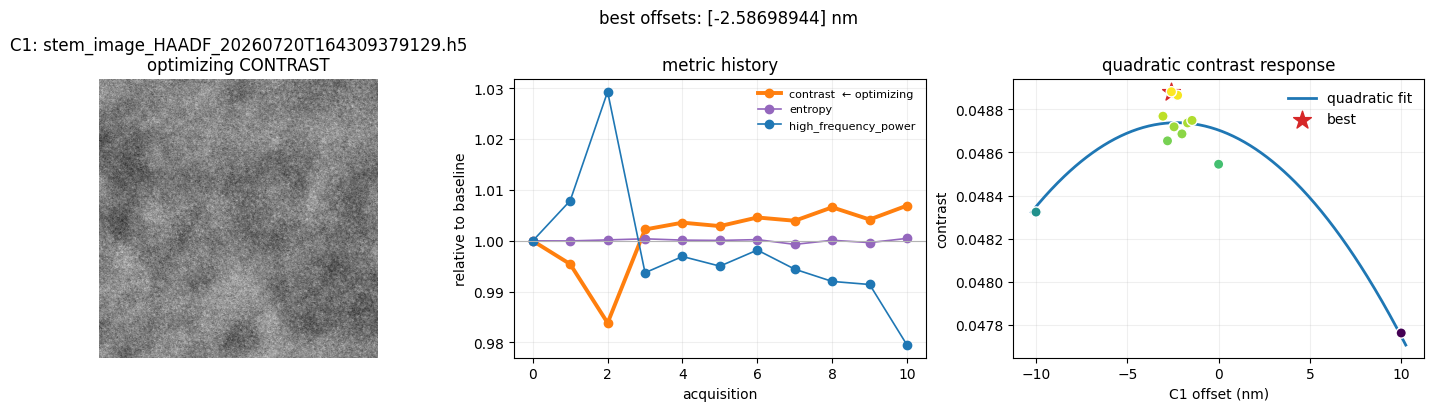

C1 complete; optimized contrast: 0.0488824
contrast=0.0488824, entropy=0.964678, high_frequency_power=0.554431
offsets=[-2.58698944] nm, final trust radius=3.702 nm


In [19]:
C1_STEP_SIZE = 10e-9  # meters; adjust this first
C1_MAX_ITERATIONS = 8

c1_result = hill_climb_aberration(
    "C1", C1_STEP_SIZE, components=1, max_iterations=C1_MAX_ITERATIONS
)

## A1 hill climb

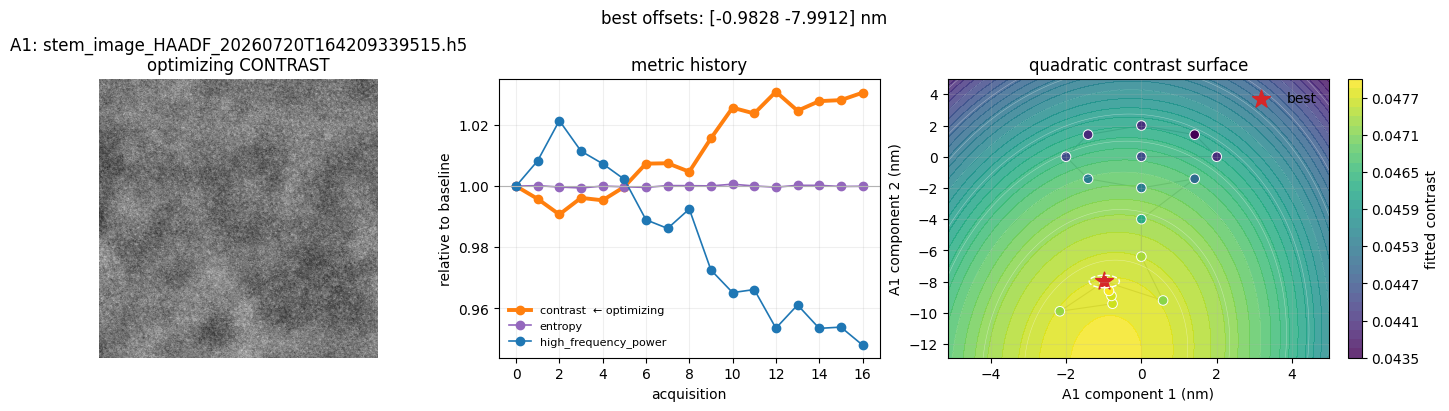

A1 complete; optimized contrast: 0.0479025
contrast=0.0479025, entropy=0.963571, high_frequency_power=0.585405
offsets=[-0.9828 -7.9912] nm, final trust radius=0.401 nm


In [18]:
A1_STEP_SIZE = 2e-9  # meters; adjust this first
A1_MAX_ITERATIONS = 8

a1_result = hill_climb_aberration(
    "A1", A1_STEP_SIZE, components=2, max_iterations=A1_MAX_ITERATIONS
)

## B2 hill climb

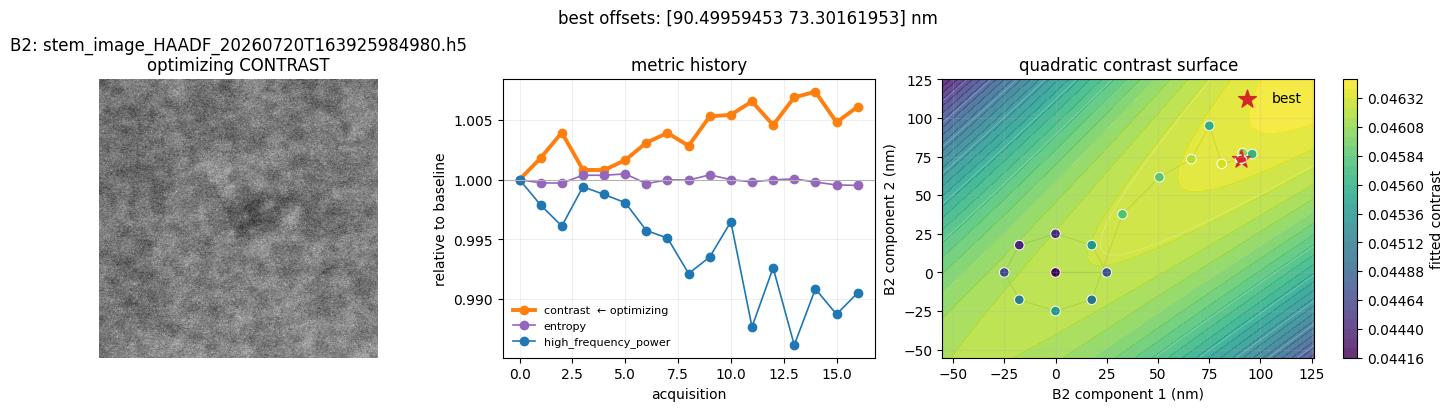

B2 complete; optimized contrast: 0.0464166
contrast=0.0464166, entropy=0.963302, high_frequency_power=0.63503
offsets=[90.49959453 73.30161953] nm, final trust radius=2.715 nm


In [13]:
B2_STEP_SIZE = 25e-9  # meters; adjust this first
B2_MAX_ITERATIONS = 8

b2_result = hill_climb_aberration(
    "B2", B2_STEP_SIZE, components=2, max_iterations=B2_MAX_ITERATIONS
)

## A2 hill climb

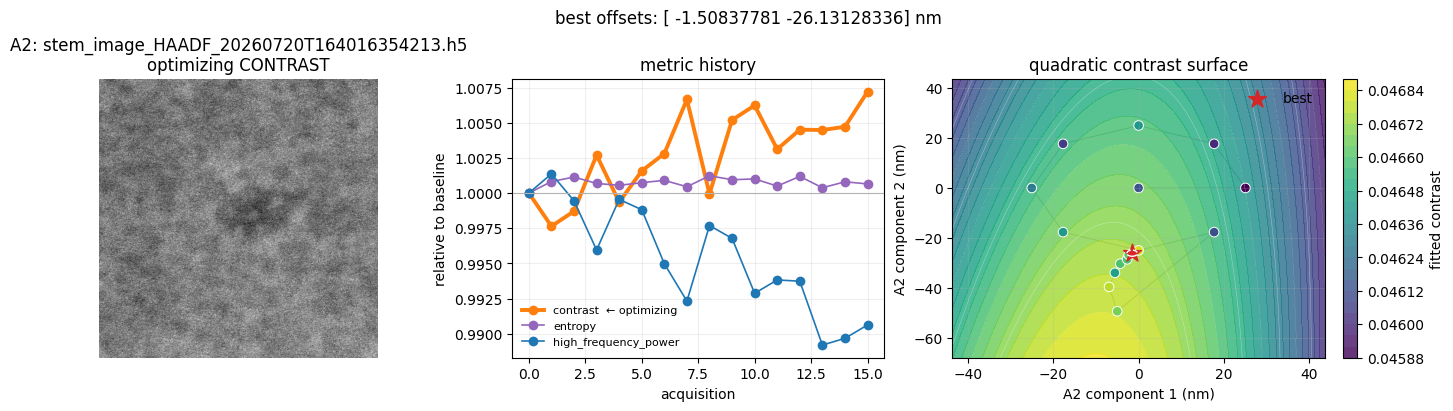

A2 complete; optimized contrast: 0.0468532
contrast=0.0468532, entropy=0.963148, high_frequency_power=0.625152
offsets=[ -1.50837781 -26.13128336] nm, final trust radius=1.226 nm


In [14]:
A2_STEP_SIZE = 25e-9  # meters; adjust this first
A2_MAX_ITERATIONS = 8

a2_result = hill_climb_aberration(
    "A2", A2_STEP_SIZE, components=2, max_iterations=A2_MAX_ITERATIONS
)